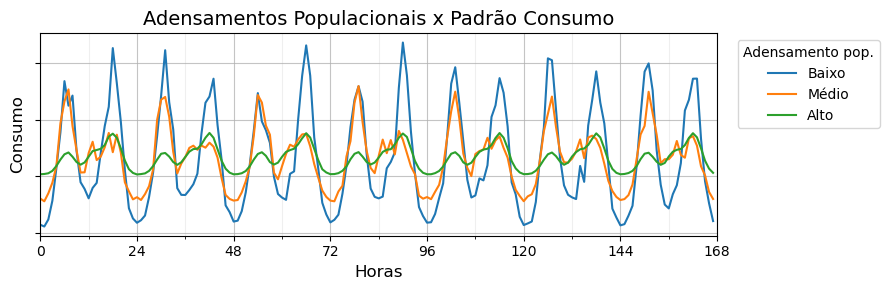

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from utils.Tbx_Simulation import generate_weekly_consumption_patterns, plot_node_time_series
from utils.configs import DISTRIBUTION_PATTERNS

low_config = DISTRIBUTION_PATTERNS.get('low')
cnsp_LOW = generate_weekly_consumption_patterns(base_demand=10, n_intervals=24, n_days=7,
                                                morning_peak=low_config[0], afternoon_peak=low_config[1],
                                                evening_peak=low_config[2], night_consumption=low_config[3],
                                                variation_strength=low_config[4])

med_config = DISTRIBUTION_PATTERNS.get('medium')
cnsp_MED = generate_weekly_consumption_patterns(base_demand=10, n_intervals=24, n_days=7,
                                                morning_peak=med_config[0], afternoon_peak=med_config[1],
                                                evening_peak=med_config[2], night_consumption=med_config[3],
                                                variation_strength=med_config[4])

high_config = DISTRIBUTION_PATTERNS.get('high')
cnsp_HIGH = generate_weekly_consumption_patterns(base_demand=10, n_intervals=24, n_days=7,
                                                 morning_peak=high_config[0], afternoon_peak=high_config[1],
                                                 evening_peak=high_config[2], night_consumption=high_config[3],
                                                 variation_strength=high_config[4])

qwe = {'Baixo': {'full_series': np.concatenate(cnsp_LOW)},
       'Médio': {'full_series': np.concatenate(cnsp_MED)},
       'Alto': {'full_series': np.concatenate(cnsp_HIGH)}
       }

plt.figure(figsize=(9, 3))
for node_id in ['Baixo', 'Médio', 'Alto']:
    if node_id not in qwe:
        print(f"Node {node_id} not found.")
        continue

    series = qwe[node_id]['full_series']

    plt.plot(series, label=node_id)

major_ticks = np.arange(0, len(series) + 1, 24)
minor_ticks = np.arange(0, len(series) + 1, 12)

plt.xticks(major_ticks)
plt.xticks(minor_ticks, minor=True)

plt.gca().set_yticklabels([])

plt.grid(which='minor', alpha=0.2)
plt.grid(which='major', alpha=0.75)

plt.xlim(0,168)

plt.xlabel('Horas', fontsize= 12)
plt.ylabel('Consumo', fontsize= 12)

plt.title('Adensamentos Populacionais x Padrão Consumo', fontsize = 14)
plt.legend(title = 'Adensamento pop.', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('img_A.pdf', dpi = 500)
plt.show()

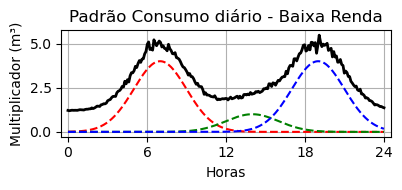

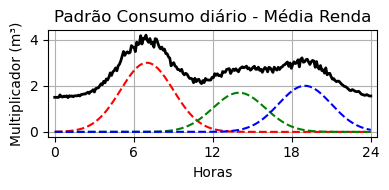

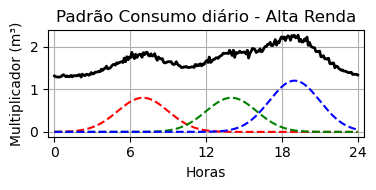

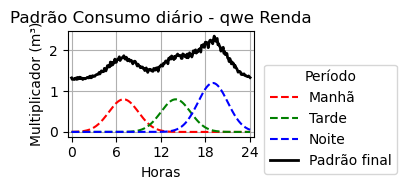

In [82]:
import numpy as np
import matplotlib.pyplot as plt

def generate_daily_consumption_pattern(tag, daily_consumption=1.0, n_intervals=48,
                                       morning_peak=1.5, evening_peak=1.3, afternoon_peak=1.4,
                                       night_consumption=0.5, variation_strength=0.05,
                                       plot=True):
    """
    Generates and plots a daily consumption pattern with Gaussian peaks for morning, afternoon, and evening.

    Parameters:
    - daily_consumption: Total daily consumption to normalize to.
    - n_intervals: Number of intervals (default is 48 for 30-min intervals).
    - morning_peak: Peak multiplier for morning Gaussian.
    - evening_peak: Peak multiplier for evening Gaussian.
    - afternoon_peak: Peak multiplier for afternoon Gaussian.
    - night_consumption: Base consumption during non-peak hours.
    - variation_strength: Std dev of random variation.
    - plot: Whether to plot the pattern.

    Returns:
    - daily_pattern_scaled: Normalized daily consumption pattern (np.array).
    """
    time = np.linspace(0, 24, n_intervals)

    # Gaussian peaks
    morning = np.exp(-0.5 * ((time - 7) / 2) ** 2)
    afternoon = np.exp(-0.5 * ((time - 14) / 2) ** 2)
    evening = np.exp(-0.5 * ((time - 19) / 2) ** 2)

    # Combined pattern with base night consumption
    pattern = (morning_peak * morning +
               afternoon_peak * afternoon +
               evening_peak * evening +
               night_consumption * (1 - morning - afternoon - evening))

    # Add random variation
    random_variation = np.random.normal(1, variation_strength, n_intervals)
    daily_pattern = pattern * random_variation + daily_consumption

    # Normalize
    daily_pattern_total = np.sum(daily_pattern)
    if np.isnan(daily_pattern_total) or np.isinf(daily_pattern_total) or daily_pattern_total == 0:
        raise ValueError("Invalid total consumption calculated.")

    daily_pattern_scaled = daily_pattern / daily_pattern_total * daily_consumption

    if plot:
        plt.figure(figsize=(4, 2))
        plt.plot(time, morning_peak * morning, 'r--', label='Manhã')
        plt.plot(time, afternoon_peak * afternoon, 'g--', label='Tarde')
        plt.plot(time, evening_peak * evening, 'b--', label='Noite')
        plt.plot(time, daily_pattern, 'k-', label='Padrão final', linewidth=2)
        plt.title(f'Padrão Consumo diário - {tag}')
        plt.xlabel('Horas')
        plt.ylabel('Multiplicador (m³)')
        if 'qwe' in tag : plt.legend(title = 'Período', bbox_to_anchor = (1.02,.75))
        
        major_ticks = np.arange(0, 24 + 1, 6)
        minor_ticks = np.arange(0, 24 + 1, 12)
        
        plt.xticks(major_ticks)
        plt.xticks(minor_ticks, minor=True)
        plt.xlim(-0.5,24.5)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'img_{tag}.pdf', dpi = 500)
        plt.show()

    return daily_pattern_scaled


low_multipliers = generate_daily_consumption_pattern(daily_consumption=1.0, n_intervals=240,
                                        morning_peak=low_config[0], afternoon_peak=low_config[1],
                                                evening_peak=low_config[2], night_consumption=low_config[3],
                                                variation_strength=0.05, tag = 'Baixa Renda')

med_multipliers = generate_daily_consumption_pattern(daily_consumption=1.0, n_intervals=240,
                                        morning_peak=med_config[0], afternoon_peak=med_config[1],
                                                evening_peak=med_config[2], night_consumption=med_config[3],
                                                variation_strength=0.05, tag = 'Média Renda')

high_multipliers = generate_daily_consumption_pattern(daily_consumption=1.0, n_intervals=240,
                                        morning_peak=high_config[0], afternoon_peak=high_config[1],
                                                evening_peak=high_config[2], night_consumption=high_config[3],
                                                variation_strength=0.05, tag = 'Alta Renda')

high_multipliers = generate_daily_consumption_pattern(daily_consumption=1.0, n_intervals=240,
                                        morning_peak=high_config[0], afternoon_peak=high_config[1],
                                                evening_peak=high_config[2], night_consumption=high_config[3],
                                                variation_strength=0.05, tag = 'qwe Renda')